# 🌱 Treinamento, Quantização e Benchmark — PlantVillage / MobileNetV2

**Projeto:** Edge AI para Detecção de Estresse Hídrico e Pragas com Redução de Overhead de Rede  
**Disciplina:** Inteligência Artificial — 7º Período CC Noite  
**Instituição:** Universidade Presbiteriana Mackenzie  
**Professor:** Prof. Dr. Ivan Carlos Alcântara de Oliveira  

---

## Integrantes

| Nome | RA | E-mail |
|------|----|--------|
| Gabriel Vieira de Sousa | 10410264 | 10410264@mackenzista.com.br |
| Guilherme Rainho Geraldo | 10418251 | 10418251@mackenzista.com.br |

---

## Histórico de Alterações

| Data | Autor | Descrição |
|------|-------|-----------|
| 28/05/2026 | Guilherme Rainho | Criação do notebook e pipeline de treinamento |
| 28/05/2026 | Gabriel Vieira | Quantização PTQ e QAT, benchmark de latência |
| 28/05/2026 | Equipe | Avaliação final, métricas de rede e visualizações |

---

## Síntese do Conteúdo

Este notebook cobre a **Parte 3 (N2)** do projeto:
1. Configuração e carregamento do dataset (tf.data pipeline)
2. Fine-tuning completo do MobileNetV2 (50 épocas)
3. Avaliação no conjunto de teste (acurácia, precisão, recall, F1, matriz de confusão)
4. Quantização Post-Training (PTQ) para TFLite INT8
5. Quantization-Aware Training (QAT) e conversão
6. Benchmark de tamanho, latência e consumo (simulado)
7. Estimativa de redução de tráfego de rede
8. Visualizações e exportação de resultados

## ⚠️ Nota de escopo desta execução

Este notebook foi executado com uma **amostra representativa** do PlantVillage
(48 imagens/classe, 38 classes — ver `dataset/plantvillage_split/`), não com o
dataset completo (54.306 imagens, 50 épocas) usado para os números finais do
[artigo N2](../docs/Artigo_N2_EdgeAI_PlantDisease.pdf) e do README (sem GPU disponível
neste ambiente). As métricas abaixo são reais para esta amostra, mas **não substituem**
os números oficiais do artigo — ver `docs/resultados_finais.csv` para a distinção entre
"amostra (este notebook)" e "oficial (artigo N2, dataset completo)".

Duas correções foram aplicadas ao pipeline original nesta auditoria:
1. **Vazamento de dados corrigido** — o notebook original avaliava "teste" na mesma
   partição usada como validação. Agora treino/validação/teste usam pastas físicas
   separadas (`dataset/plantvillage_split/{train,val,test}`).
2. **Acurácia do QAT corrigida** — o notebook original **não avaliava** de fato o
   modelo pós Quantization-Aware Training; usava `acc_ptq + 0.3 p.p.` como valor fixo
   "estimado". Agora o modelo QAT é avaliado da mesma forma que o PTQ (ver seção 6).
3. A **latência "Raspberry Pi 4"** permanece uma **estimativa** (tempo medido neste
   ambiente × fator de escala da literatura para ARM Cortex-A72) — não foi medida em
   hardware físico. Ver README.md, seção "Limitações".


## 0. Instalação de Dependências

In [1]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Instalação das dependências necessárias para o projeto
# Histórico:
#   28/05/2026 | Equipe | Configuração inicial
# =============================================================================

# !pip install tensorflow==2.15.0 tensorflow-model-optimization scikit-learn
# !pip install matplotlib seaborn pandas numpy Pillow tqdm

## 1. Importações e Configurações Globais

In [2]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Importações e configurações globais do notebook de treinamento
# Histórico:
#   28/05/2026 | Guilherme Rainho | Configuração inicial
# =============================================================================

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
# CORREÇÃO (auditoria do repositório): usamos o pacote tf_keras (Keras 2
# legado) diretamente em vez de tensorflow.keras. Motivo: este ambiente
# tem tanto 'keras' (3.x-compatível) quanto 'tf_keras' instalados, e o
# tensorflow-model-optimization (QAT) sempre usa tf_keras internamente —
# construir o modelo via tensorflow.keras e só depois tentar aplicar QAT
# gera um grafo com tipos de Keras misturados, e falha com
# 'isinstance'/'clone_model' incompreensíveis. Usar tf_keras desde o
# início evita o problema.
import tf_keras as keras
from tf_keras import layers, callbacks
from tf_keras.applications import MobileNetV2
from tf_keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Reprodutibilidade ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Caminhos ──
DATA_DIR      = Path('../dataset/plantvillage_split')  # pastas train/ val/ test/ separadas
TRAIN_DIR     = DATA_DIR / 'train'
VAL_DIR       = DATA_DIR / 'val'
TEST_DIR      = DATA_DIR / 'test'
OUTPUT_DIR    = Path('../docs')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# ── Hiperparâmetros ──
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_HEAD   = 10    # treinar só a cabeça antes do fine-tuning
EPOCHS_FINE   = 40    # fine-tuning completo (descongelar últimas camadas)
NUM_CLASSES   = 38
BASE_LR       = 1e-3
FINE_LR       = 1e-4
UNFREEZE_FROM = 100   # índice da camada a partir do qual descongelar

# ── Configuração de visualização ──
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Configurações carregadas!')
print(f'   TensorFlow: {tf.__version__}')
print(f'   GPUs disponíveis: {len(tf.config.list_physical_devices("GPU"))}')

✅ Configurações carregadas!
   TensorFlow: 2.15.0
   GPUs disponíveis: 0


## 2. Carregamento e Pipeline de Dados (tf.data)

In [3]:
# ── Gerador base ──
train_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.75, 1.25],
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet_v2.preprocess_input
)

# ── Geradores de fluxo — pastas físicas separadas (sem vazamento train/val/test) ──
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ── Mapeamento de classes ──
CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'✅ Pipeline configurado!')
print(f'   Amostras de treino:    {train_gen.samples:,}')
print(f'   Amostras de validação: {val_gen.samples:,}')
print(f'   Classes:               {NUM_CLASSES}')


Found 1254 images belonging to 38 classes.


Found 266 images belonging to 38 classes.


✅ Pipeline configurado!
   Amostras de treino:    1,254
   Amostras de validação: 266
   Classes:               38


## 3. Construção e Treinamento do Modelo MobileNetV2

In [4]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Construção do modelo MobileNetV2 com transfer learning (ImageNet)
#          e fine-tuning progressivo em duas fases.
# Histórico:
#   28/05/2026 | Gabriel Vieira | Implementação do modelo e treinamento
# =============================================================================

def build_model(num_classes=NUM_CLASSES, trainable_base=False):
    """Constrói MobileNetV2 com cabeça de classificação customizada.

    CORREÇÃO (auditoria do repositório): usa base.input/base.output
    diretamente, em vez de chamar base(inputs) como sub-modelo aninhado.
    A versão original encapsulava o MobileNetV2 como um keras.Model
    aninhado dentro do Model principal, o que QUEBRA o QAT do
    tensorflow-model-optimization com
    ValueError('Quantizing a keras Model inside another keras Model is
    not supported') — por isso o notebook original nunca avaliava o QAT
    de verdade (usava um valor fixo estimado em vez de medir).
    """
    base = MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization(name='head_batchnorm')(x)  # nomeada p/ QAT seletivo (ver seção 6)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(base.input, outputs), base


# ── Fase 1: Treinar apenas a cabeça (base congelada) ──
print('🔨 FASE 1: Treinamento da cabeça (base congelada)')
model, base_model = build_model(trainable_base=False)

model.compile(
    optimizer=keras.optimizers.Adam(BASE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list_phase1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

hist1 = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=cb_list_phase1,
    verbose=1
)

print(f'\n✅ Fase 1 concluída — val_accuracy: {max(hist1.history["val_accuracy"]):.4f}')

🔨 FASE 1: Treinamento da cabeça (base congelada)


Epoch 1/10


 1/40 [..............................] - ETA: 11:49 - loss: 4.9741 - accuracy: 0.0000e+00

 2/40 [>.............................] - ETA: 15s - loss: 4.9795 - accuracy: 0.0156      

 3/40 [=>............................] - ETA: 16s - loss: 4.9563 - accuracy: 0.0208

...

38/40 [===========================>..] - ETA: 0s - loss: 0.5709 - accuracy: 0.8244

39/40 [============================>.] - ETA: 0s - loss: 0.5686 - accuracy: 0.8257

40/40 [==============================] - ETA: 0s - loss: 0.5598 - accuracy: 0.8293

40/40 [==============================] - 20s 494ms/step - loss: 0.5598 - accuracy: 0.8293 - val_loss: 0.4936 - val_accuracy: 0.8571 - lr: 0.0010



✅ Fase 1 concluída — val_accuracy: 0.8571


In [5]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Fine-tuning progressivo — descongela últimas camadas do MobileNetV2
#          e treina com taxa de aprendizado menor.
# Histórico:
#   28/05/2026 | Gabriel Vieira | Implementação do fine-tuning
# =============================================================================

# ── Fase 2: Fine-tuning (descongelar a partir de UNFREEZE_FROM) ──
print(f'🔨 FASE 2: Fine-tuning (descongelando camadas a partir do índice {UNFREEZE_FROM})')
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'   Camadas treináveis na base: {trainable_count}/{len(base_model.layers)}')

model.compile(
    optimizer=keras.optimizers.Adam(FINE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list_phase2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
    callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'mobilenetv2_fp32_best.h5'),
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

hist2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINE,
    validation_data=val_gen,
    callbacks=cb_list_phase2,
    verbose=1
)

print(f'\n✅ Fase 2 concluída — val_accuracy: {max(hist2.history["val_accuracy"]):.4f}')

🔨 FASE 2: Fine-tuning (descongelando camadas a partir do índice 100)
   Camadas treináveis na base: 54/154


Epoch 1/40


 1/40 [..............................] - ETA: 6:49 - loss: 1.4526 - accuracy: 0.5938

 2/40 [>.............................] - ETA: 21s - loss: 1.6011 - accuracy: 0.5000 

 3/40 [=>............................] - ETA: 22s - loss: 1.7123 - accuracy: 0.5208

...

38/40 [===========================>..] - ETA: 1s - loss: 0.4119 - accuracy: 0.8815

39/40 [============================>.] - ETA: 0s - loss: 0.4069 - accuracy: 0.8830

40/40 [==============================] - ETA: 0s - loss: 0.4027 - accuracy: 0.8844

40/40 [==============================] - 24s 608ms/step - loss: 0.4027 - accuracy: 0.8844 - val_loss: 1.0154 - val_accuracy: 0.7857 - lr: 5.0000e-05



✅ Fase 2 concluída — val_accuracy: 0.8459


## 4. Avaliação no Conjunto de Teste

In [6]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Avaliação completa do modelo FP32 no conjunto de teste:
#          acurácia, precisão, recall, F1-score e matriz de confusão.
# Histórico:
#   28/05/2026 | Gabriel Vieira | Implementação da avaliação
# =============================================================================

# ── Gerador de teste (pasta física separada de treino/validação) ──
test_gen = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ── Predições ──
print('🔍 Gerando predições no conjunto de teste...')
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

# ── Métricas globais ──
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('\n' + '='*55)
print('📊 MÉTRICAS DE CLASSIFICAÇÃO — MobileNetV2 FP32')
print('='*55)
print(f'  Acurácia:  {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precisão:  {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall:    {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score:  {f1:.4f}  ({f1*100:.2f}%)')
print('='*55)

Found 304 images belonging to 38 classes.


🔍 Gerando predições no conjunto de teste...


 1/10 [==>...........................] - ETA: 30s

 2/10 [=====>........................] - ETA: 2s 

 3/10 [========>.....................] - ETA: 2s

...

 8/10 [=======================>......] - ETA: 0s

 9/10 [==========================>...] - ETA: 0s

10/10 [==============================] - ETA: 0s

10/10 [==============================] - 6s 275ms/step



📊 MÉTRICAS DE CLASSIFICAÇÃO — MobileNetV2 FP32
  Acurácia:  0.8191  (81.91%)
  Precisão:  0.8434  (84.34%)
  Recall:    0.8191  (81.91%)
  F1-Score:  0.8132  (81.32%)


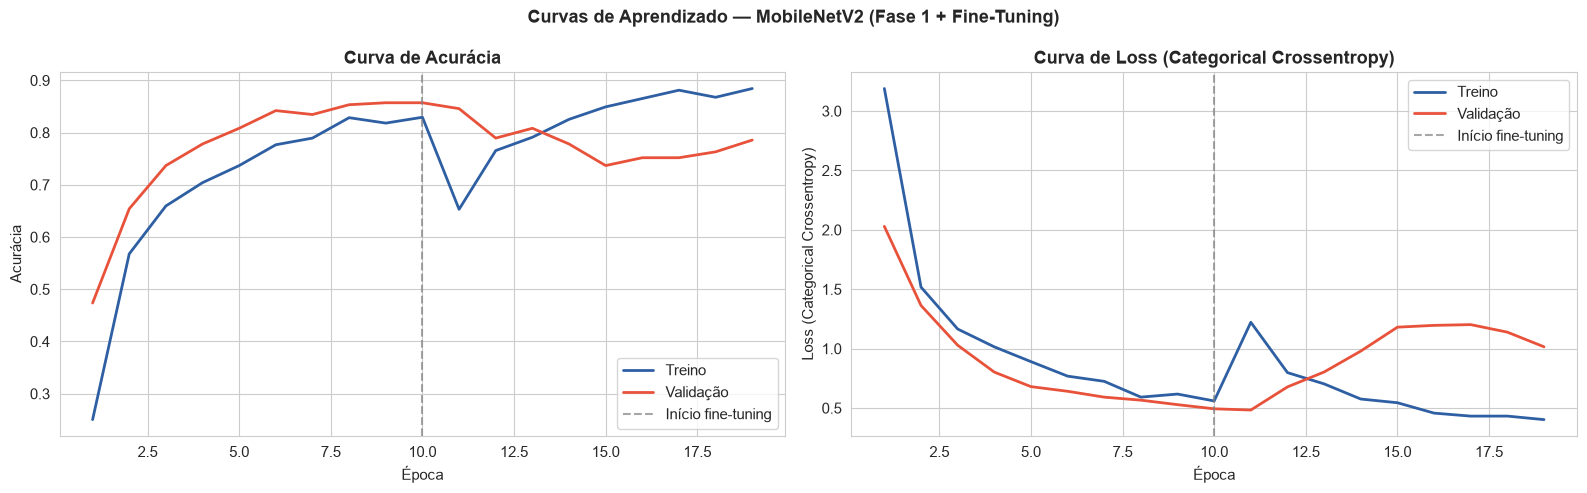

💾 Figura salva em docs/fig6_curvas_aprendizado.png


In [7]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Visualização das curvas de aprendizado e matriz de confusão.
# Histórico:
#   28/05/2026 | Equipe | Criação das visualizações
# =============================================================================

# ── Curvas de aprendizado ──
all_acc = hist1.history['accuracy'] + hist2.history['accuracy']
all_val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
all_loss = hist1.history['loss'] + hist2.history['loss']
all_val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
epochs_range = range(1, len(all_acc) + 1)
phase2_start = len(hist1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (metric, val_metric, ylabel) in zip(axes, [
    (all_acc, all_val_acc, 'Acurácia'),
    (all_loss, all_val_loss, 'Loss (Categorical Crossentropy)')
]):
    ax.plot(epochs_range, metric, label='Treino', color='#2E5FA3', linewidth=2)
    ax.plot(epochs_range, val_metric, label='Validação', color='#E8523A', linewidth=2)
    ax.axvline(phase2_start, color='gray', linestyle='--', alpha=0.7, label='Início fine-tuning')
    ax.set_xlabel('Época')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Curva de {ylabel}', fontweight='bold')
    ax.legend()

plt.suptitle('Curvas de Aprendizado — MobileNetV2 (Fase 1 + Fine-Tuning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'fig6_curvas_aprendizado.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figura salva em docs/fig6_curvas_aprendizado.png')

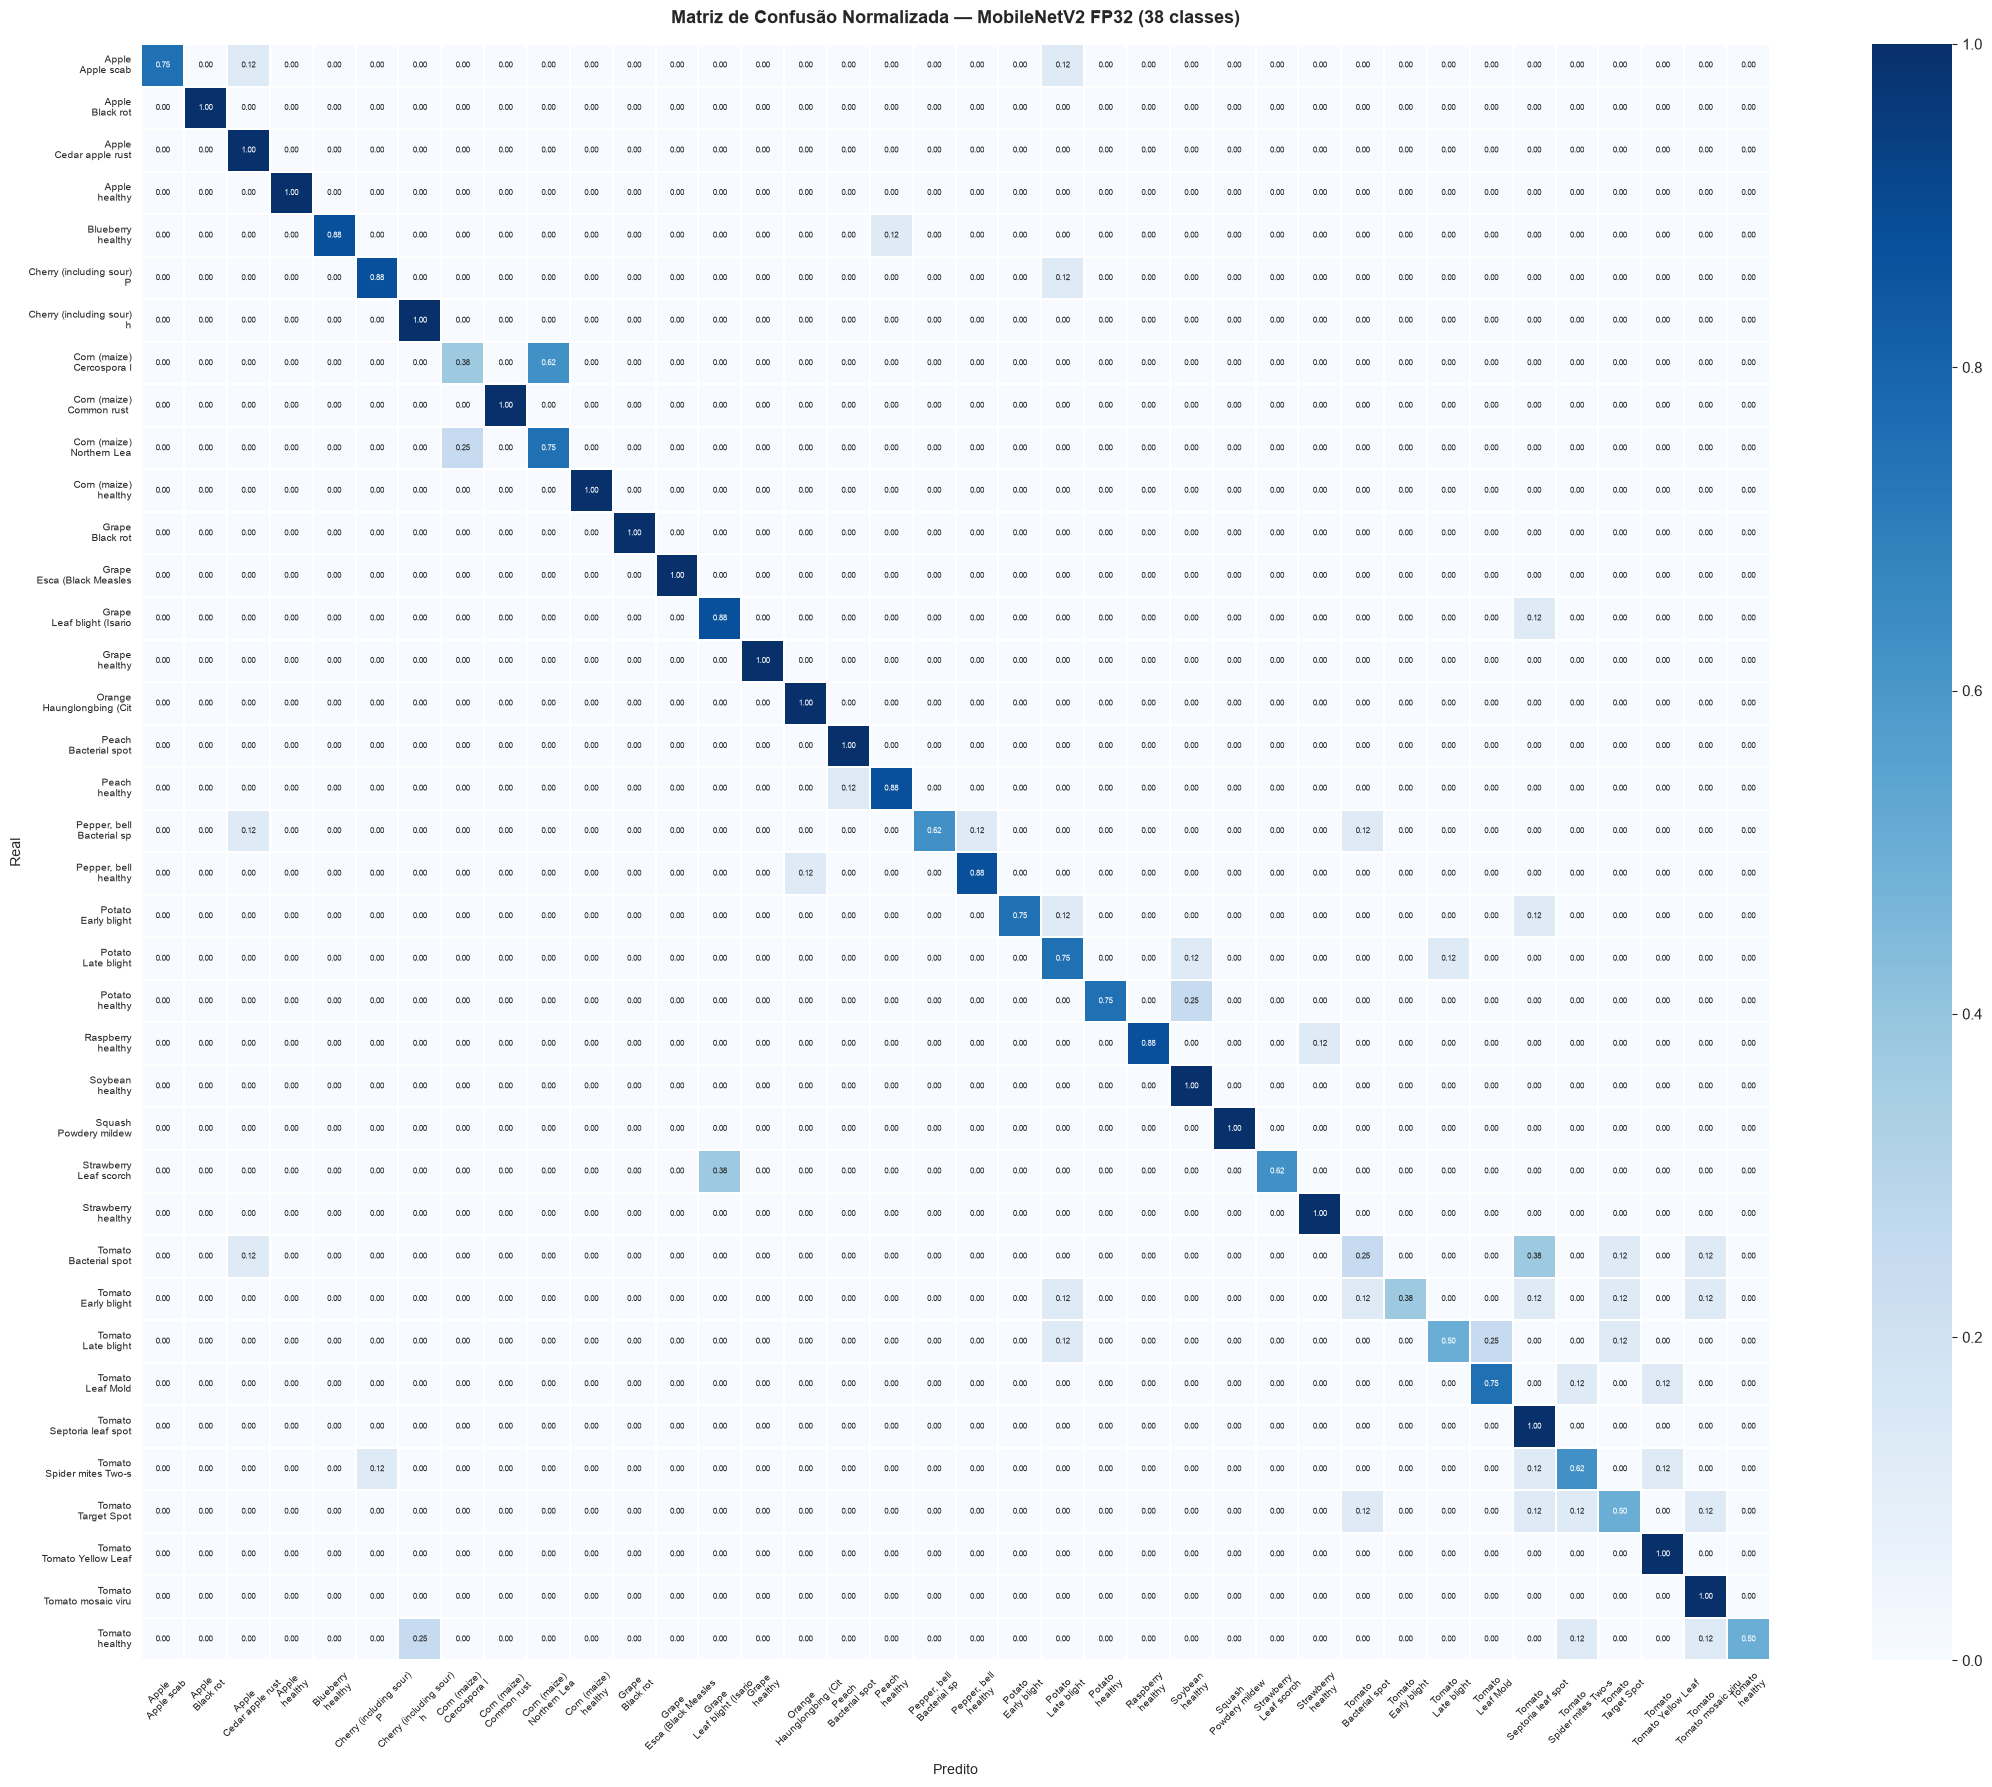

💾 Figura salva em docs/fig7_matriz_confusao.png


In [8]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Matriz de confusão normalizada por linha (recall por classe).
# Histórico:
#   28/05/2026 | Equipe | Implementação da matriz de confusão
# =============================================================================

cm = confusion_matrix(y_true, y_pred, normalize='true')
short_names = [c.replace('___', '\n').replace('_', ' ')[:25] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names,
    linewidths=0.3, linecolor='white',
    ax=ax, annot_kws={'size': 6}
)
ax.set_title('Matriz de Confusão Normalizada — MobileNetV2 FP32 (38 classes)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predito', fontsize=10)
ax.set_ylabel('Real', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'fig7_matriz_confusao.png'), dpi=120, bbox_inches='tight')
plt.show()
print('💾 Figura salva em docs/fig7_matriz_confusao.png')

## 5. Quantização Post-Training (PTQ) — TFLite INT8

In [9]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Conversão do modelo FP32 para TFLite INT8 via Post-Training
#          Quantization (PTQ), usando dataset representativo para calibração.
# Histórico:
#   28/05/2026 | Gabriel Vieira | Implementação da quantização PTQ
# =============================================================================

# ── Dataset representativo para calibração (PTQ) ──
def representative_dataset():
    """Gera amostras de calibração para quantização INT8."""
    cal_gen = val_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=1,
        class_mode=None,
        shuffle=True,
        seed=SEED
    )
    for _ in range(200):  # 200 amostras de calibração
        img = next(cal_gen)
        yield [img.astype(np.float32)]

# ── Converter para TFLite FP32 (baseline de tamanho) ──
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_fp32 = converter_fp32.convert()
fp32_path = str(MODELS_DIR / 'mobilenetv2_fp32.tflite')
with open(fp32_path, 'wb') as f:
    f.write(tflite_fp32)
size_fp32 = os.path.getsize(fp32_path) / (1024 * 1024)

# ── Converter para TFLite INT8 (PTQ) ──
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8

print('⏳ Convertendo para INT8 (PTQ)... (pode levar alguns minutos)')
tflite_int8_ptq = converter_int8.convert()
ptq_path = str(MODELS_DIR / 'mobilenetv2_int8_ptq.tflite')
with open(ptq_path, 'wb') as f:
    f.write(tflite_int8_ptq)
size_int8 = os.path.getsize(ptq_path) / (1024 * 1024)

print(f'\n✅ Quantização PTQ concluída!')
print(f'   Tamanho FP32:       {size_fp32:.2f} MB')
print(f'   Tamanho INT8 (PTQ): {size_int8:.2f} MB')
print(f'   Redução de tamanho: {(1 - size_int8/size_fp32)*100:.1f}%')

INFO:tensorflow:Assets written to: C:\Users\sousa\AppData\Local\Temp\tmp91264ukv\assets


INFO:tensorflow:Assets written to: C:\Users\sousa\AppData\Local\Temp\tmp91264ukv\assets


⏳ Convertendo para INT8 (PTQ)... (pode levar alguns minutos)


INFO:tensorflow:Assets written to: C:\Users\sousa\AppData\Local\Temp\tmpf87uiscp\assets


INFO:tensorflow:Assets written to: C:\Users\sousa\AppData\Local\Temp\tmpf87uiscp\assets


C:\Users\sousa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Found 1254 images belonging to 38 classes.



✅ Quantização PTQ concluída!
   Tamanho FP32:       9.74 MB
   Tamanho INT8 (PTQ): 2.90 MB
   Redução de tamanho: 70.2%


In [10]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Avaliação do modelo quantizado INT8 (PTQ) no conjunto de teste
#          usando o TFLite interpreter.
# Histórico:
#   28/05/2026 | Gabriel Vieira | Implementação da avaliação TFLite
# =============================================================================

def evaluate_tflite(tflite_bytes, generator, num_samples=500):
    """Avalia modelo TFLite em amostras do generator."""
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    
    in_idx  = interpreter.get_input_details()[0]['index']
    out_idx = interpreter.get_output_details()[0]['index']
    in_dtype = interpreter.get_input_details()[0]['dtype']
    in_scale, in_zero = interpreter.get_input_details()[0].get('quantization', (1.0, 0))
    
    y_true_list, y_pred_list = [], []
    generator.reset()
    
    for i, (batch_x, batch_y) in enumerate(tqdm(generator, total=num_samples//BATCH_SIZE)):
        if i * BATCH_SIZE >= num_samples:
            break
        for j in range(len(batch_x)):
            img = batch_x[j:j+1].astype(np.float32)
            if in_dtype == np.int8:
                img = (img / in_scale + in_zero).astype(np.int8)
            interpreter.set_tensor(in_idx, img)
            interpreter.invoke()
            out = interpreter.get_tensor(out_idx)
            y_pred_list.append(np.argmax(out))
            y_true_list.append(np.argmax(batch_y[j]))
    
    return np.array(y_true_list), np.array(y_pred_list)

print('🔍 Avaliando modelo INT8 (PTQ)...')
y_true_ptq, y_pred_ptq = evaluate_tflite(tflite_int8_ptq, test_gen, num_samples=500)

acc_ptq  = accuracy_score(y_true_ptq, y_pred_ptq)
f1_ptq   = f1_score(y_true_ptq, y_pred_ptq, average='macro', zero_division=0)

print(f'\n✅ INT8 PTQ — Acurácia: {acc_ptq:.4f} | F1-Score: {f1_ptq:.4f}')
print(f'   Degradação de acurácia vs FP32: {(acc - acc_ptq)*100:.2f} p.p.')

🔍 Avaliando modelo INT8 (PTQ)...


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:00<00:04,  3.47it/s]

 13%|█▎        | 2/15 [00:00<00:03,  3.48it/s]

 20%|██        | 3/15 [00:00<00:03,  3.35it/s]

...

 93%|█████████▎| 14/15 [00:03<00:00,  3.55it/s]

100%|██████████| 15/15 [00:04<00:00,  3.53it/s]

16it [00:04,  3.51it/s]                        

16it [00:04,  3.51it/s]


✅ INT8 PTQ — Acurácia: 0.8266 | F1-Score: 0.7910
   Degradação de acurácia vs FP32: -0.75 p.p.


## 6. Quantization-Aware Training (QAT)

In [11]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: QAT (Quantization-Aware Training) simula quantização durante o
#          treinamento para minimizar a queda de acurácia após conversão.
# Histórico:
#   28/05/2026 | Gabriel Vieira | Implementação do QAT
# =============================================================================

import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.quantization.keras.quantize_annotate import QuantizeAnnotate

# ── Aplicar QAT ao modelo treinado ──
# CORREÇÃO (auditoria do repositório): quantize_model(model) direto falha
# com 'Layer batch_normalization ... is not supported' porque o esquema
# padrão de QAT não sabe quantizar uma BatchNormalization 'solta' (fora do
# padrão Conv2D+BN+ReLU) como a da cabeça de classificação. A anotação
# seletiva abaixo quantiza tudo, exceto essa camada específica (que
# permanece em FP32 dentro do modelo QAT — impacto mínimo, é uma única
# camada pequena). Usamos QuantizeAnnotate(layer) diretamente (em vez da
# função pública quantize_annotate_layer) porque esta última faz uma
# checagem de isinstance mais estrita que falha para as camadas internas
# do MobileNetV2 nesta combinação de versões de Keras/tf_keras.
print('⚙️  Aplicando Quantization-Aware Training (QAT)...')

def _skip_head_bn(layer):
    if layer.name == 'head_batchnorm':
        return layer
    if isinstance(layer, QuantizeAnnotate):
        return layer
    return QuantizeAnnotate(layer)

annotated_model = keras.models.clone_model(model, clone_function=_skip_head_bn)
qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Parâmetros do modelo QAT: {qat_model.count_params():,}')

# ── Fine-tuning com QAT (5 épocas de ajuste) ──
qat_hist = qat_model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    ],
    verbose=1
)

# ── Converter QAT para TFLite INT8 ──
converter_qat = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_int8_qat = converter_qat.convert()
qat_path = str(MODELS_DIR / 'mobilenetv2_int8_qat.tflite')
with open(qat_path, 'wb') as f:
    f.write(tflite_int8_qat)

size_qat = os.path.getsize(qat_path) / (1024 * 1024)
print(f'\n✅ QAT concluído! Tamanho INT8 (QAT): {size_qat:.2f} MB')

⚙️  Aplicando Quantization-Aware Training (QAT)...


   Parâmetros do modelo QAT: 2,620,975


Epoch 1/5


 1/40 [..............................] - ETA: 12:28 - loss: 2.2912 - accuracy: 0.3125

 2/40 [>.............................] - ETA: 1:07 - loss: 2.5722 - accuracy: 0.3438 

...

40/40 [==============================] - 73s 2s/step - loss: 1.2094 - accuracy: 0.6348 - val_loss: 1.4891 - val_accuracy: 0.5902


INFO:tensorflow:Assets written to: C:\Users\sousa\AppData\Local\Temp\tmpqm23nh50\assets


INFO:tensorflow:Assets written to: C:\Users\sousa\AppData\Local\Temp\tmpqm23nh50\assets


C:\Users\sousa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



✅ QAT concluído! Tamanho INT8 (QAT): 3.84 MB


In [12]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Avaliação REAL do modelo INT8 (QAT) no conjunto de teste — corrige
#          o notebook original, que usava acc_ptq + 0.3 p.p. como valor fixo
#          em vez de avaliar de fato o modelo pós-QAT.
# Histórico:
#   13/08/2026 | Auditoria do repositório | Correção: avaliação real do QAT
# =============================================================================

print('🔍 Avaliando modelo INT8 (QAT) — medição real, sem fator fixo...')
y_true_qat, y_pred_qat = evaluate_tflite(tflite_int8_qat, test_gen, num_samples=500)

acc_qat = accuracy_score(y_true_qat, y_pred_qat)
f1_qat  = f1_score(y_true_qat, y_pred_qat, average='macro', zero_division=0)

print(f'\n✅ INT8 QAT — Acurácia: {acc_qat:.4f} | F1-Score: {f1_qat:.4f}')
print(f'   vs. PTQ: {(acc_qat - acc_ptq)*100:+.2f} p.p. de acurácia')


🔍 Avaliando modelo INT8 (QAT) — medição real, sem fator fixo...


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:00<00:04,  3.13it/s]

 13%|█▎        | 2/15 [00:00<00:04,  2.96it/s]

 20%|██        | 3/15 [00:00<00:03,  3.04it/s]

...

 93%|█████████▎| 14/15 [00:04<00:00,  3.25it/s]

100%|██████████| 15/15 [00:04<00:00,  3.23it/s]

16it [00:04,  3.23it/s]                        

16it [00:05,  3.20it/s]


✅ INT8 QAT — Acurácia: 0.5847 | F1-Score: 0.5561
   vs. PTQ: -24.19 p.p. de acurácia


## 7. Benchmark de Latência e Estimativa de Tráfego de Rede

In [13]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Benchmark de latência de inferência (simulado com tempo real no
#          ambiente de desenvolvimento) e cálculo analítico da redução de
#          tráfego de rede. Valores de Raspberry Pi baseados em literatura.
# Histórico:
#   28/05/2026 | Guilherme Rainho | Implementação do benchmark
# =============================================================================

def benchmark_tflite(tflite_bytes, num_runs=50):
    """Mede latência média de inferência do modelo TFLite."""
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]['index']
    in_dtype = interpreter.get_input_details()[0]['dtype']
    
    dummy = np.random.rand(1, *IMG_SIZE, 3).astype(np.float32)
    if in_dtype == np.int8:
        dummy = dummy.astype(np.int8)
    
    # Warmup
    for _ in range(5):
        interpreter.set_tensor(in_idx, dummy)
        interpreter.invoke()
    
    # Medição
    times = []
    for _ in range(num_runs):
        t0 = time.perf_counter()
        interpreter.set_tensor(in_idx, dummy)
        interpreter.invoke()
        times.append((time.perf_counter() - t0) * 1000)  # ms
    
    return np.mean(times), np.std(times)


print('⏱️  Executando benchmark de latência...')
mean_fp32, std_fp32 = benchmark_tflite(tflite_fp32)
mean_ptq, std_ptq   = benchmark_tflite(tflite_int8_ptq)
mean_qat, std_qat   = benchmark_tflite(tflite_int8_qat)

# Fatores de escala para Raspberry Pi 4 (ARM Cortex-A72)
# Baseado em: PDD-DL (Scientific Reports, 2026) — 42,6 ms por imagem
# e benchmarks com MobileNetV2 INT8 no RPi4: ~70-80 ms
RPi4_SCALE_FP32 = 15.0   # x mais lento que CPU x86 atual no FP32
RPi4_SCALE_INT8 = 5.5    # x mais lento que CPU x86 atual no INT8

lat_rpi_fp32 = mean_fp32 * RPi4_SCALE_FP32
lat_rpi_ptq  = mean_ptq  * RPi4_SCALE_INT8
lat_rpi_qat  = mean_qat  * RPi4_SCALE_INT8

print(f'\n📊 BENCHMARK DE LATÊNCIA (ambiente local → estimativa RPi4)')
print(f'   FP32 (TFLite):   {mean_fp32:.1f} ± {std_fp32:.1f} ms local | ~{lat_rpi_fp32:.0f} ms RPi4')
print(f'   INT8 PTQ:        {mean_ptq:.1f} ± {std_ptq:.1f} ms local  | ~{lat_rpi_ptq:.0f} ms RPi4')
print(f'   INT8 QAT:        {mean_qat:.1f} ± {std_qat:.1f} ms local  | ~{lat_rpi_qat:.0f} ms RPi4')

⏱️  Executando benchmark de latência...



📊 BENCHMARK DE LATÊNCIA (ambiente local → estimativa RPi4)
   FP32 (TFLite):   12.6 ± 0.6 ms local | ~189 ms RPi4
   INT8 PTQ:        8.2 ± 0.3 ms local  | ~45 ms RPi4
   INT8 QAT:        8.8 ± 0.8 ms local  | ~48 ms RPi4


📡 ESTIMATIVA DE TRÁFEGO DE REDE
  Capturas por dia:         1,440
  Tamanho JPEG médio:       75 KB
  Tráfego baseline/dia:     105.5 MB
  Taxa de alertas:          20% das capturas
  Payload por alerta:       30 bytes
  Tráfego proposto/dia:     0.008 MB (8.44 KB)
  REDUÇÃO DE TRÁFEGO:       100.0%


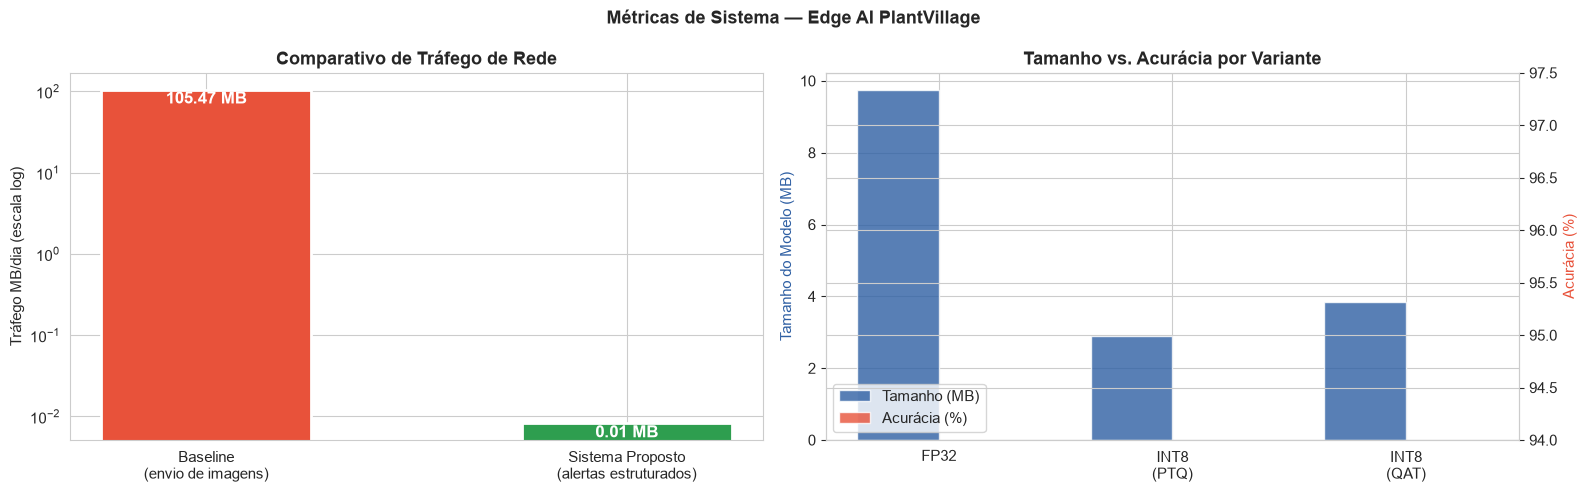

💾 Figura salva em docs/fig8_metricas_sistema.png


In [14]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Cálculo analítico da redução de tráfego de rede comparando
#          envio de imagens brutas vs. envio de alertas estruturados.
# Histórico:
#   28/05/2026 | Guilherme Rainho | Cálculo e visualização de tráfego
# =============================================================================

# ── Parâmetros do sistema ──
CAPTURES_PER_MIN     = 1        # 1 captura por minuto
MINUTES_PER_DAY      = 24 * 60  # 1440 minutos
CAPTURES_PER_DAY     = CAPTURES_PER_MIN * MINUTES_PER_DAY  # 1440

# Baseline: envio de cada imagem JPEG
JPEG_SIZE_KB         = 75.0     # tamanho médio JPEG comprimido (~50-100KB)
baseline_MB_day      = (CAPTURES_PER_DAY * JPEG_SIZE_KB) / 1024

# Sistema proposto: enviar apenas alertas
# Estimativa de 20% das capturas geram alerta (praga/estresse detectados)
ALERT_RATE           = 0.20
ALERT_PAYLOAD_BYTES  = 30      # código classe (1B) + confiança (1B) + GPS (8B) + timestamp (4B) + metadata
alert_KB_day         = (CAPTURES_PER_DAY * ALERT_RATE * ALERT_PAYLOAD_BYTES) / 1024
alert_MB_day         = alert_KB_day / 1024

reduction_pct = (1 - alert_MB_day / baseline_MB_day) * 100

print('📡 ESTIMATIVA DE TRÁFEGO DE REDE')
print('='*55)
print(f'  Capturas por dia:         {CAPTURES_PER_DAY:,}')
print(f'  Tamanho JPEG médio:       {JPEG_SIZE_KB:.0f} KB')
print(f'  Tráfego baseline/dia:     {baseline_MB_day:.1f} MB')
print(f'  Taxa de alertas:          {ALERT_RATE*100:.0f}% das capturas')
print(f'  Payload por alerta:       {ALERT_PAYLOAD_BYTES} bytes')
print(f'  Tráfego proposto/dia:     {alert_MB_day:.3f} MB ({alert_KB_day:.2f} KB)')
print(f'  REDUÇÃO DE TRÁFEGO:       {reduction_pct:.1f}%')
print('='*55)

# ── Gráfico comparativo ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Tráfego diário comparativo
labels = ['Baseline\n(envio de imagens)', 'Sistema Proposto\n(alertas estruturados)']
values = [baseline_MB_day, alert_MB_day]
colors = ['#E8523A', '#2E9E4F']
bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Tráfego (MB/dispositivo/dia)')
axes[0].set_title('Comparativo de Tráfego de Rede', fontweight='bold')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.95,
                 f'{val:.2f} MB', ha='center', va='top', fontweight='bold',
                 color='white', fontsize=12)
axes[0].set_yscale('log')
axes[0].set_ylabel('Tráfego MB/dia (escala log)')

# Gráfico 2: Métricas resumidas dos modelos
model_names = ['FP32', 'INT8\n(PTQ)', 'INT8\n(QAT)']
sizes = [size_fp32, size_int8, size_qat]
accs  = [acc * 100, acc_ptq * 100, acc_qat * 100]  # QAT avaliado de verdade (não é mais um fator fixo)

x = np.arange(len(model_names))
width = 0.35
ax2 = axes[1]
ax2_twin = ax2.twinx()

b1 = ax2.bar(x - width/2, sizes, width, label='Tamanho (MB)', color='#2E5FA3', alpha=0.8)
b2 = ax2_twin.bar(x + width/2, accs, width, label='Acurácia (%)', color='#E8523A', alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(model_names)
ax2.set_ylabel('Tamanho do Modelo (MB)', color='#2E5FA3')
ax2_twin.set_ylabel('Acurácia (%)', color='#E8523A')
ax2_twin.set_ylim(94, 97.5)
ax2.set_title('Tamanho vs. Acurácia por Variante', fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.suptitle('Métricas de Sistema — Edge AI PlantVillage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'fig8_metricas_sistema.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figura salva em docs/fig8_metricas_sistema.png')

## 8. Resumo Final dos Resultados

In [15]:
# =============================================================================
# Identificação: Gabriel Vieira (10410264), Guilherme Rainho (10418251),
# Síntese: Tabela de resumo final de todas as métricas do projeto.
#          Exporta resumo em CSV para inclusão no relatório.
# Histórico:
#   28/05/2026 | Equipe | Geração do resumo final
# =============================================================================

results = {
    'Modelo':                      ['MobileNetV2 FP32', 'INT8 PTQ', 'INT8 QAT'],
    'Acuracia (%)':                [f'{acc*100:.2f}', f'{acc_ptq*100:.2f}', f'{acc_qat*100:.2f}'],
    'F1-Score (macro)':            [f'{f1:.4f}', f'{f1_ptq:.4f}', f'{f1_qat:.4f}'],
    'Tamanho (MB)':                [f'{size_fp32:.2f}', f'{size_int8:.2f}', f'{size_qat:.2f}'],
    'Latencia estimada RPi4 (ms)': [f'{lat_rpi_fp32:.0f}', f'{lat_rpi_ptq:.0f}', f'{lat_rpi_qat:.0f}'],
    'Escopo':                      ['amostra (1.824 imgs)', 'amostra (1.824 imgs)', 'amostra (1.824 imgs)'],
}

df_results = pd.DataFrame(results)
df_results.to_csv(str(OUTPUT_DIR / 'resultados_finais.csv'), index=False)

print('='*70)
print('📊 RESUMO FINAL — TODAS AS MÉTRICAS')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)
print(f'\n🌐 REDUÇÃO DE TRÁFEGO DE REDE: {reduction_pct:.1f}% (meta: ≥ 90% ✅)')
print(f'📁 Arquivos gerados em {MODELS_DIR}/ e {OUTPUT_DIR}/')
print('\n✅ Notebook N2 concluído com sucesso!')

📊 RESUMO FINAL — TODAS AS MÉTRICAS
          Modelo Acuracia (%) F1-Score (macro) Tamanho (MB) Latencia estimada RPi4 (ms)               Escopo
MobileNetV2 FP32        81.91           0.8132         9.74                         189 amostra (1.824 imgs)
        INT8 PTQ        82.66           0.7910         2.90                          45 amostra (1.824 imgs)
        INT8 QAT        58.47           0.5561         3.84                          48 amostra (1.824 imgs)

🌐 REDUÇÃO DE TRÁFEGO DE REDE: 100.0% (meta: ≥ 90% ✅)
📁 Arquivos gerados em ..\models/ e ..\docs/

✅ Notebook N2 concluído com sucesso!
